In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/netflix_dataset.csv")

print("Shape:", df.shape)

df.head()

Shape: (999994, 6)


,user_id,movie_id,rating,date,year,title
0,578449,12470,3,2004-12-08,1996,Twister
1,1073589,5181,3,2004-11-29,2003,Under the Tuscan Sun
2,1642316,15474,3,2004-11-08,2001,Rock Star
3,1814017,13129,4,2003-12-19,1998,Sex and the City: Season 1
4,2315012,4841,1,2005-01-28,1995,Judge Dredd


In [2]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["year"].astype("Int64")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999994 entries, 0 to 999993
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   user_id   999994 non-null  int64         
 1   movie_id  999994 non-null  int64         
 2   rating    999994 non-null  int64         
 3   date      999994 non-null  datetime64[ns]
 4   year      999994 non-null  Int64         
 5   title     999994 non-null  object        
dtypes: Int64(1), datetime64[ns](1), int64(3), object(1)
memory usage: 46.7+ MB


In [3]:
df.isnull().sum()

user_id     0
movie_id    0
rating      0
date        0
year        0
title       0
dtype: int64

In [3]:
user_counts = df["user_id"].value_counts()

active_users = user_counts[
    user_counts >= 10
].index

df_10 = df[
    df["user_id"].isin(active_users)
]

print("Shape:", df_10.shape)
print("Users:", df_10["user_id"].nunique())
print("Movies:", df_10["movie_id"].nunique())

Shape: (255542, 6)
Users: 18282
Movies: 13145


In [5]:
df_10.to_csv(
    "../data/processed/model_dataset_10.csv",
    index=False
)

In [4]:
print("Number of Ratings :", len(df))
print("Unique Users      :", df["user_id"].nunique())
print("Unique Movies     :", df["movie_id"].nunique())
print("Average Rating    :", round(df["rating"].mean(), 2))
print("Duplicate Rows    :", df.duplicated().sum())

Number of Ratings : 999994
Unique Users      : 289387
Unique Movies     : 16144
Average Rating    : 3.61
Duplicate Rows    : 0


In [5]:
df["user_id"].value_counts().describe()

count    289387.000000
mean          3.455560
std           3.698691
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         176.000000
Name: count, dtype: float64

In [6]:
user_counts = df["user_id"].value_counts()

active_users = user_counts[user_counts >= 5].index

df_model = df[df["user_id"].isin(active_users)]

print("Rows:", len(df_model))
print("Users:", df_model["user_id"].nunique())
print("Movies:", df_model["movie_id"].nunique())

Rows: 579426
Users: 68716
Movies: 14792


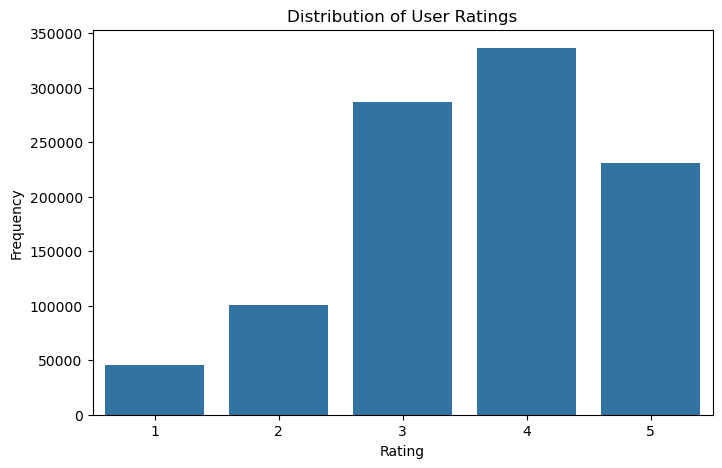

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="rating",
    data=df
)

plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

In [32]:
rating_dist = (
    df["rating"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

rating_dist

rating
1     4.574427
2    10.087961
3    28.649772
4    33.631802
5    23.056038
Name: proportion, dtype: float64

### Rating Distribution Insights

- Rating 4 is the most common user rating (33.63%).
- Ratings 4 and 5 together account for approximately 56.69% of all ratings.
- Only 14.66% of ratings are 1 or 2.
- The distribution is positively skewed, indicating that users generally provide favorable feedback.

In [33]:
popular_movies = (
    df.groupby("title")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

popular_movies

title
Miss Congeniality                                         2341
Independence Day                                          2190
The Patriot                                               2035
Twister                                                   1959
The Day After Tomorrow                                    1922
Pretty Woman                                              1919
Pirates of the Caribbean: The Curse of the Black Pearl    1866
Gone in 60 Seconds                                        1855
The Green Mile                                            1809
Armageddon                                                1806
dtype: int64

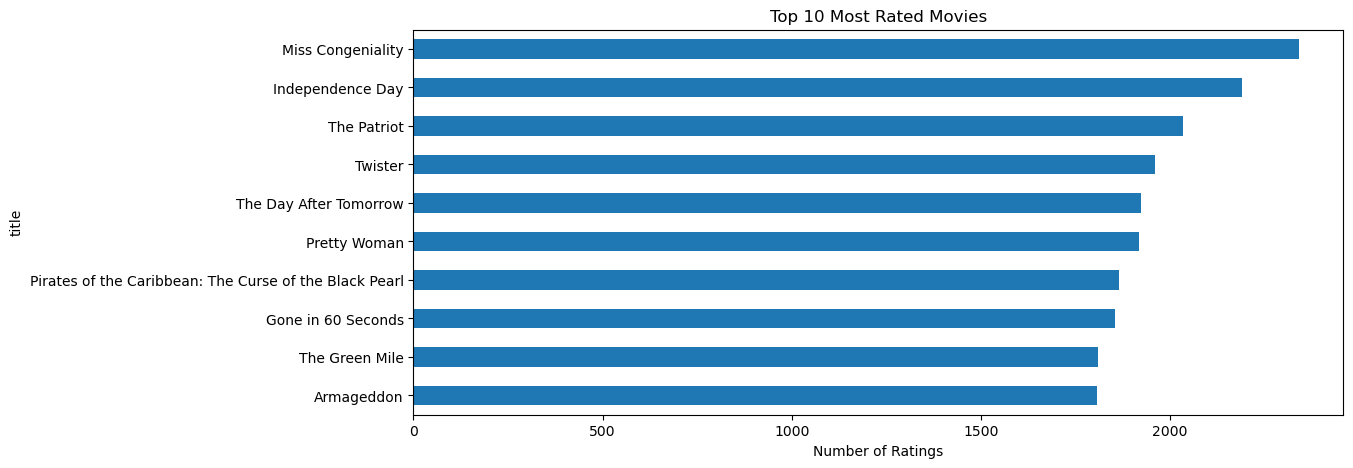

In [34]:
plt.figure(figsize=(12,5))

popular_movies.sort_values().plot(kind="barh")

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")

plt.show()

In [35]:
popular_movies = (
    df.groupby("title")
      .size()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="rating_count")
)

popular_movies

,title,rating_count
0,Miss Congeniality,2341
1,Independence Day,2190
2,The Patriot,2035
3,Twister,1959
4,The Day After Tomorrow,1922
5,Pretty Woman,1919
6,Pirates of the Caribbean: The Curse of the Bla...,1866
7,Gone in 60 Seconds,1855
8,The Green Mile,1809
9,Armageddon,1806


### Movie Popularity Analysis

The most frequently rated movies are mainstream and commercially successful titles such as *Miss Congeniality*, *Independence Day*, and *The Patriot*.

The distribution suggests that user interactions are concentrated around a relatively small set of highly popular movies. This phenomenon is common in recommendation systems and contributes to the long-tail nature of user-item interactions.

In [36]:
top_users = (
    df.groupby("user_id")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

top_users

user_id
2439493    176
305344     169
1664010    165
387418     162
2118461    151
1314869    102
2606799     98
1461435     93
2457095     92
1639792     91
dtype: int64

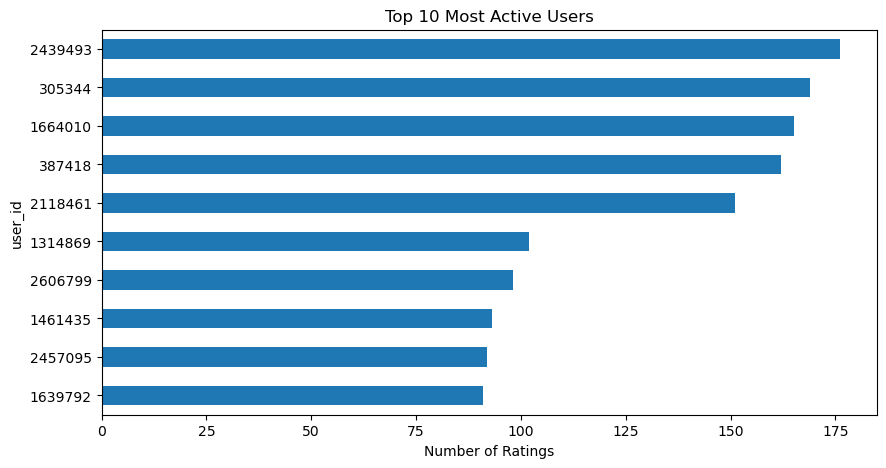

In [37]:
plt.figure(figsize=(10,5))

top_users.sort_values().plot(kind="barh")

plt.title("Top 10 Most Active Users")
plt.xlabel("Number of Ratings")

plt.show()

In [38]:
user_activity = (
    df.groupby("user_id")
      .size()
)

user_activity.describe()

count    289387.000000
mean          3.455560
std           3.698691
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         176.000000
dtype: float64

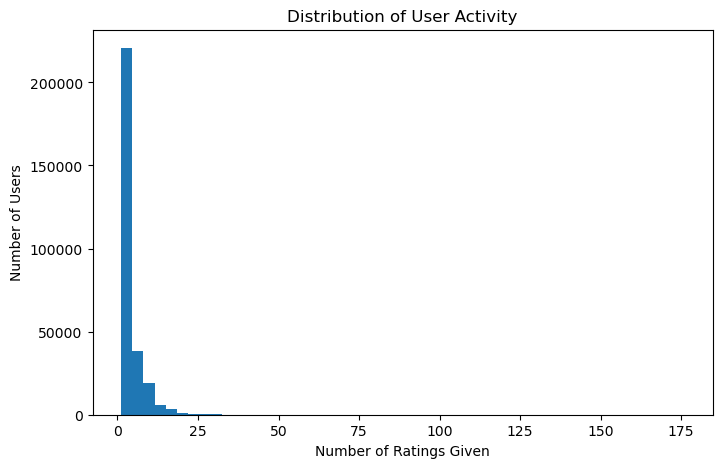

In [39]:
plt.figure(figsize=(8,5))

plt.hist(
    user_activity,
    bins=50
)

plt.title("Distribution of User Activity")
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users")

plt.show()

User activity is highly imbalanced. While the average user contributes approximately 3.46 ratings, the median user contributes only 2 ratings. This indicates that most users provide very limited interaction history, whereas a small subset of highly active users contributes a disproportionately large number of ratings.

In [40]:
num_users = df["user_id"].nunique()
num_movies = df["movie_id"].nunique()

possible_ratings = num_users * num_movies
actual_ratings = len(df)

sparsity = 1 - (actual_ratings / possible_ratings)

print(f"Sparsity: {sparsity:.4%}")

Sparsity: 99.9786%


The user-movie interaction matrix exhibits a sparsity of 99.98%, indicating that users have rated only a tiny fraction of the available movies. Such extreme sparsity is characteristic of real-world recommendation systems and motivates the use of collaborative filtering and latent factor models to infer missing preferences.

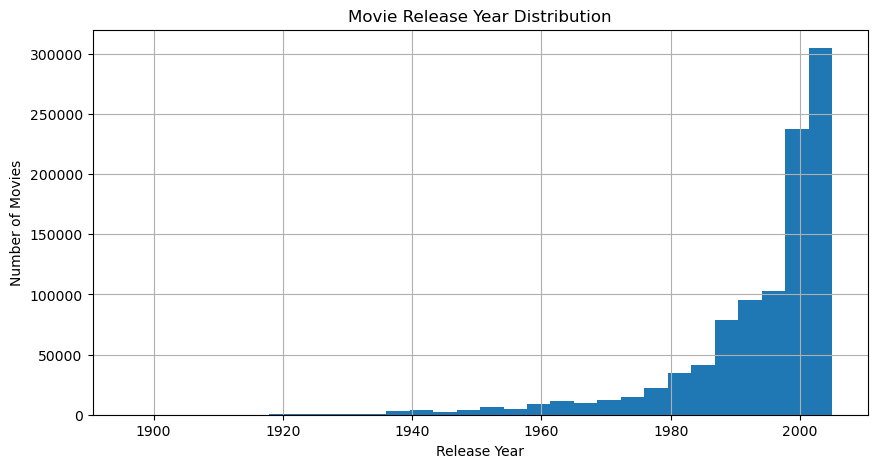

In [41]:
plt.figure(figsize=(10,5))

df["year"].hist(bins=30)

plt.title("Movie Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

In [42]:
user_activity = df.groupby("user_id").size()

cold_users = (user_activity <= 3).sum()

print(f"Cold Users: {cold_users}")
print(f"Percentage: {cold_users/len(user_activity)*100:.2f}%")

Cold Users: 196941
Percentage: 68.05%


In [43]:
movie_activity = df.groupby("movie_id").size()

cold_movies = (movie_activity <= 5).sum()

print(cold_movies)

7114


(array([5.6800e+03, 1.9000e+01, 7.1000e+01, 7.1500e+02, 3.3000e+01,
        3.6400e+02, 8.8000e+01, 1.2526e+04, 1.5800e+02, 6.8700e+02,
        1.9090e+03, 5.9360e+03, 4.0030e+03, 3.8180e+03, 1.0560e+03,
        4.5662e+04, 8.4890e+03, 1.0383e+04, 2.3493e+04, 6.3600e+03,
        1.5630e+04, 7.2530e+03, 6.3188e+04, 3.0290e+03, 1.1358e+04,
        2.1060e+03, 1.2255e+04, 4.1960e+03, 1.6700e+03, 3.7252e+04]),
 array([1.        , 1.13333333, 1.26666667, 1.4       , 1.53333333,
        1.66666667, 1.8       , 1.93333333, 2.06666667, 2.2       ,
        2.33333333, 2.46666667, 2.6       , 2.73333333, 2.86666667,
        3.        , 3.13333333, 3.26666667, 3.4       , 3.53333333,
        3.66666667, 3.8       , 3.93333333, 4.06666667, 4.2       ,
        4.33333333, 4.46666667, 4.6       , 4.73333333, 4.86666667,
        5.        ]),
 <BarContainer object of 30 artists>)

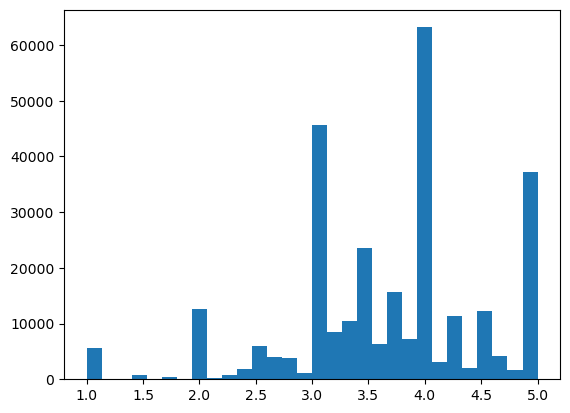

In [44]:
user_mean = df.groupby("user_id")["rating"].mean()
plt.hist(user_mean,bins=30)

In [45]:
movie_stats = df.groupby("title")["rating"].agg(["mean","std","count"])
movie_stats.sort_values("std",ascending=False)

,mean,std,count
title,,,
Young and Dangerous: The Prequel,3.0,2.828427,2
Delta Force One: The Lost Patrol,3.0,2.828427,2
Saved by the Bell: The New Class: Season 4,3.0,2.828427,2
Red Dwarf: Series 2: Bonus Material,3.0,2.828427,2
I Can't Marry You,3.0,2.828427,2
...,...,...,...
Zapped Again!,1.0,NaN,1
Zatoichi in Desperation,5.0,NaN,1
Zero Woman: Assassin Lovers,2.0,NaN,1


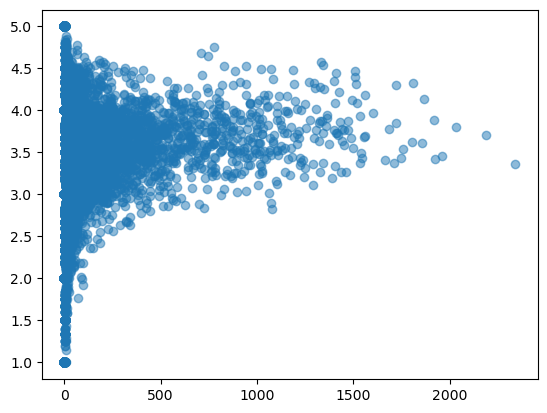

In [46]:
movie_stats = df.groupby("title").agg(
    avg_rating=("rating","mean"),
    rating_count=("rating","count")
)

plt.scatter(
    movie_stats["rating_count"],
    movie_stats["avg_rating"],
    alpha=0.5
)

In [47]:
df["decade"] = (df["year"]//10)*10
df.groupby("decade")["rating"].mean()

decade
1890    4.000000
1900    2.500000
1910    3.436364
1920    3.710059
1930    3.910115
1940    3.858745
1950    3.857757
1960    3.822567
1970    3.773472
1980    3.688118
1990    3.615743
2000    3.523205
Name: rating, dtype: float64

In [48]:
movie_counts = (
    df.groupby("movie_id")
      .size()
      .sort_values(ascending=False)
)

In [49]:
top10 = int(len(movie_counts)*0.1)

coverage = (
    movie_counts.iloc[:top10].sum()
    /
    movie_counts.sum()
)

<Axes: xlabel='rating_year'>

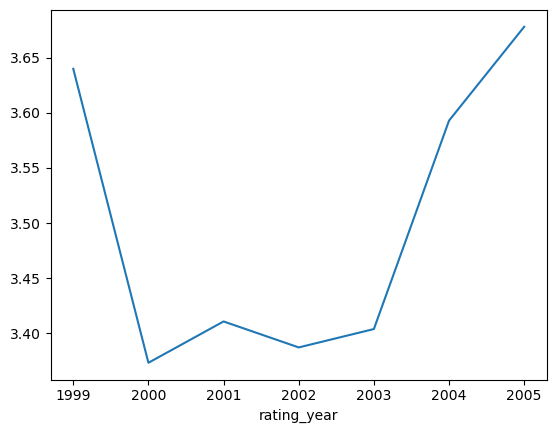

In [50]:
df["rating_year"] = df["date"].dt.year

df.groupby("rating_year")["rating"].mean().plot()

<Axes: xlabel='movie_age', ylabel='rating'>

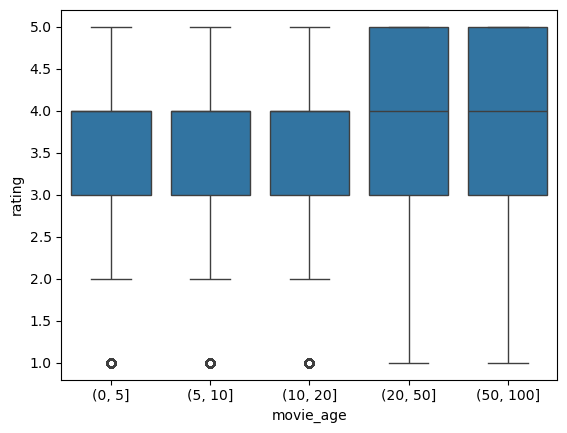

In [51]:
df["movie_age"] = (
    df["date"].dt.year
    - df["year"]
)
sns.boxplot(
    x=pd.cut(df["movie_age"],
             bins=[0,5,10,20,50,100]),
    y=df["rating"]
)

In [54]:
top_users = (
    df["user_id"]
    .value_counts()
    .head(100)
    .index
)

top_movies = (
    df["movie_id"]
    .value_counts()
    .head(100)
    .index
)

sample_df = df[
    (df["user_id"].isin(top_users))
    &
    (df["movie_id"].isin(top_movies))
]

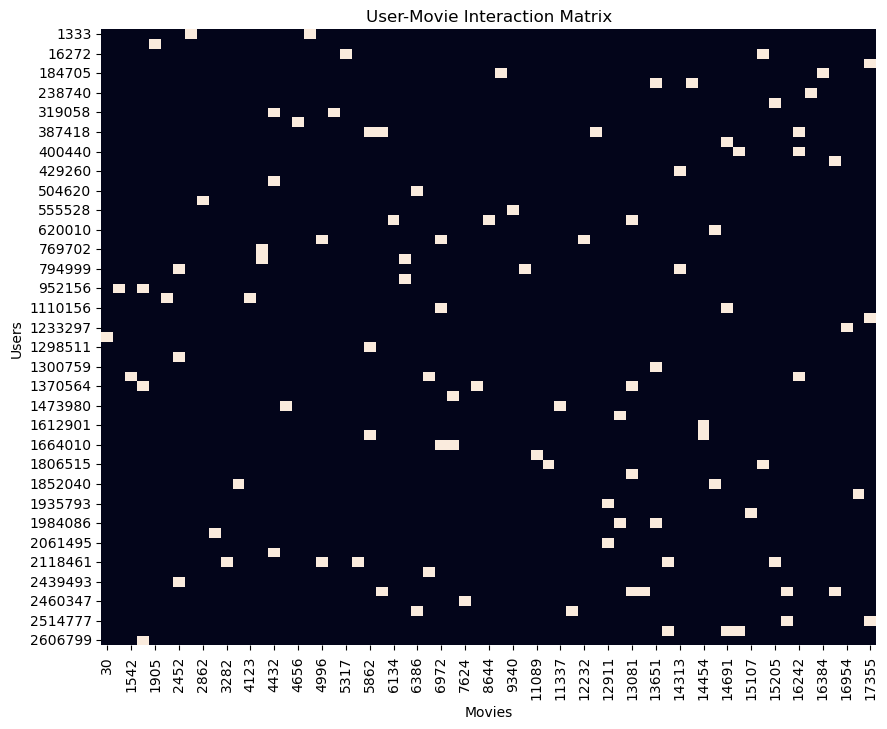

In [55]:
pivot = sample_df.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)
plt.figure(figsize=(10,8))

sns.heatmap(
    pivot.notnull(),
    cbar=False
)

plt.title("User-Movie Interaction Matrix")
plt.xlabel("Movies")
plt.ylabel("Users")

plt.show()

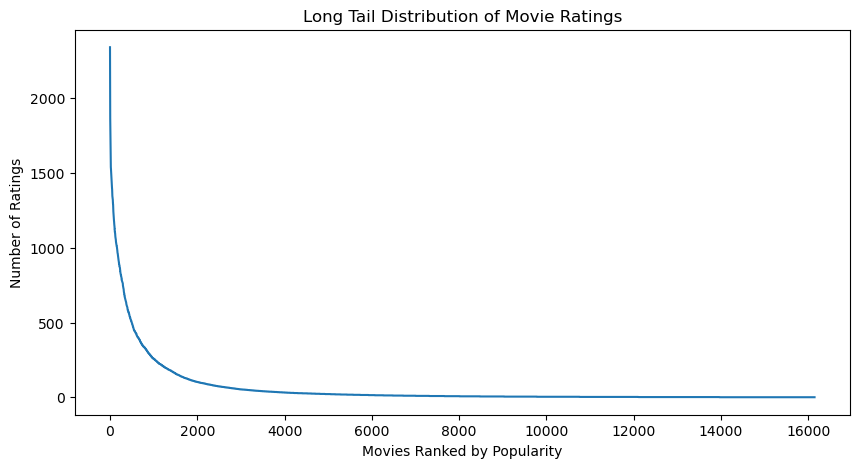

In [56]:
movie_counts = (
    df.groupby("movie_id")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

plt.plot(movie_counts.values)

plt.title("Long Tail Distribution of Movie Ratings")
plt.xlabel("Movies Ranked by Popularity")
plt.ylabel("Number of Ratings")

plt.show()